In [1]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.shape

(541909, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Missing CustomerID

In [8]:
df = df.dropna(subset=['CustomerID'])
df.shape

(406829, 8)

Remove cancelled transactions

In [9]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]


Remove negative quantity

In [10]:
df = df[df["Quantity"] > 0]

Remove negative price

In [11]:
df = df[df["UnitPrice"] > 0]

Revenue and Date Column

In [12]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

Total Revenue Analysis

In [13]:
df["Revenue"].sum()

np.float64(8911407.904)

Top 10 Product

In [14]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,100448.15
JUMBO BAG RED RETROSPOT,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68844.33
ASSORTED COLOUR BIRD ORNAMENT,56580.34
Manual,53779.93


Revenue by Country

In [15]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
country_sales

,Revenue
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


Monthly Sales Trend

In [17]:
monthly_sales = df.groupby("Month")["Revenue"].sum()
monthly_sales

,Revenue
Month,
1,569445.040
2,447137.350
3,595500.760
4,469200.361
5,678594.560
6,661213.690
7,600091.011
8,645343.900
9,952838.382


**VISUALIZATION**

Top Product Chart

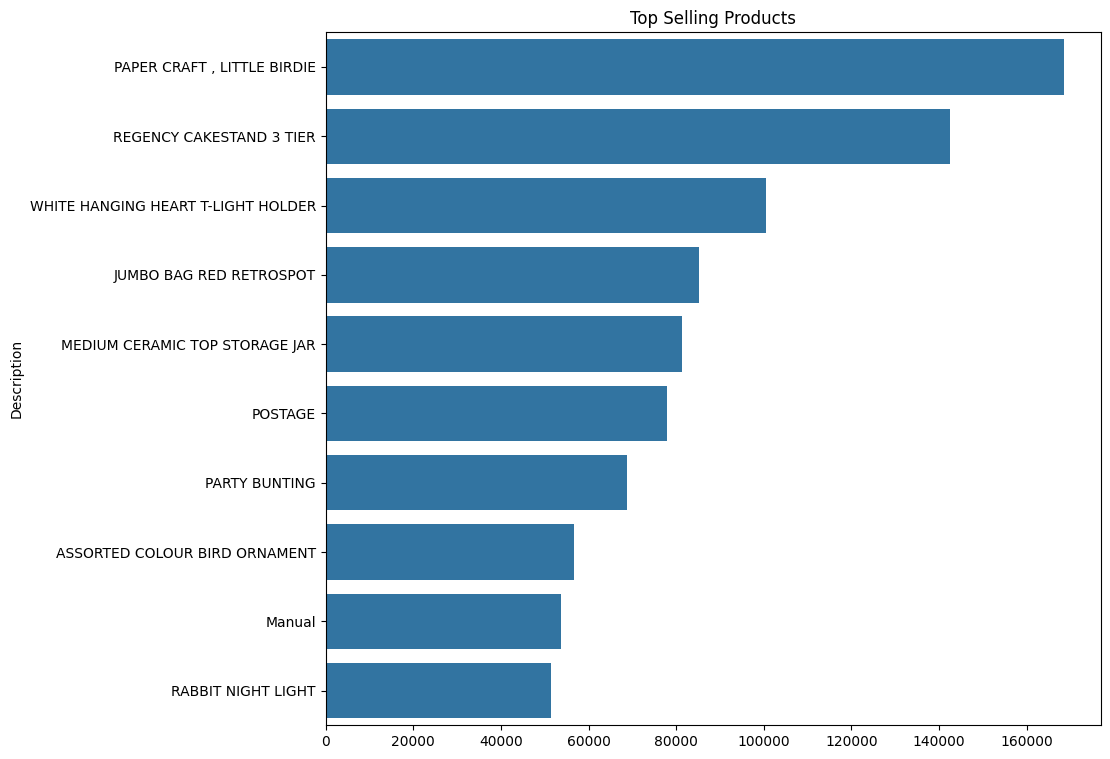

<Figure size 640x480 with 0 Axes>

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 9))
sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top Selling Products")
plt.show()
plt.savefig("top_product_chart.png")

Revenue by Country

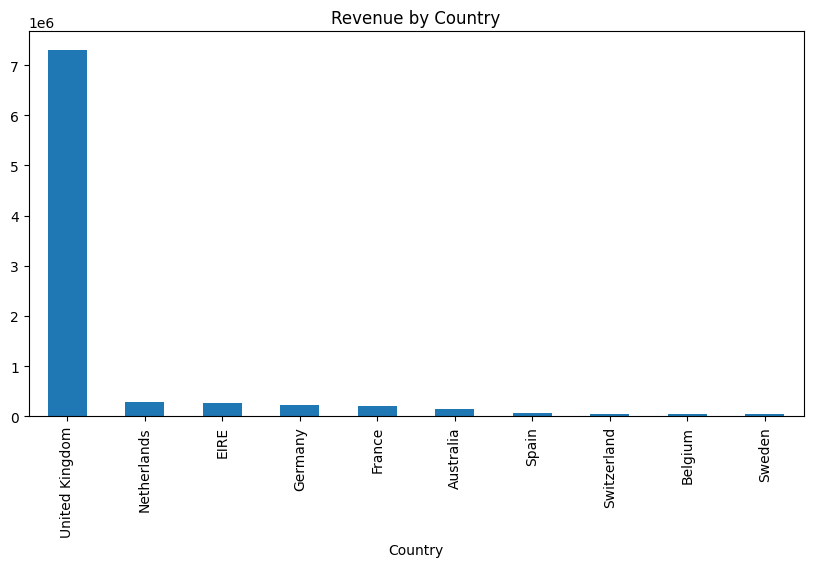

<Figure size 640x480 with 0 Axes>

In [30]:
plt.figure(figsize=(10, 5))

country_sales.head(10).plot(kind="bar")
plt.title("Revenue by Country")
plt.show()
plt.savefig("revenue_by_country.png")

Monthly Sales Trend

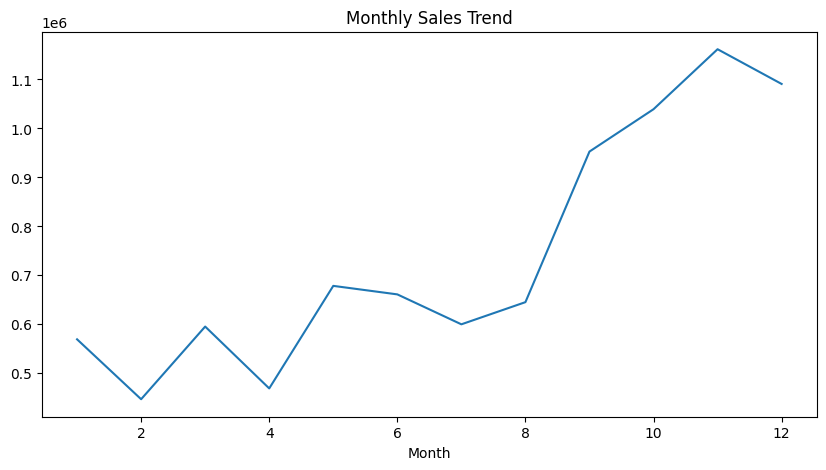

<Figure size 640x480 with 0 Axes>

In [31]:
plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.show()
plt.savefig("monthly_sales_trend.png")

**Export**

In [28]:
df.to_csv("Online_retail_clean.csv", index=False)